In [1]:
from utils import *

In [2]:
g_strength = 0.3
EJ = 9.39
EC = 2.5
EL = 0.47
E_osc = 6.77
qubit_level = 8
osc_level = 50

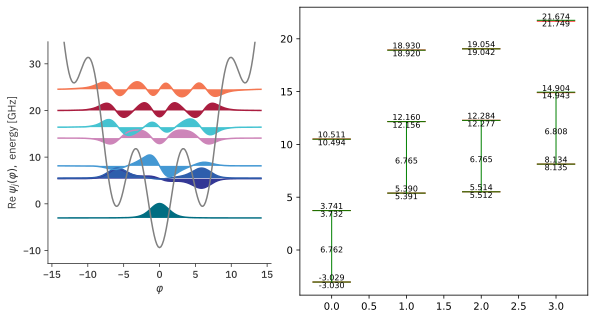

In [3]:
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
plot_specturum(qbt, osc, hilbertspace)

In [4]:
a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )
print(f"w_d: {w_d}")

amp = 0.003
def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *amp * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.07
decay_term = kappa*a

tot_time = 1000
tlist = np.linspace(0, tot_time, tot_time)[::4]


# existing_chunk_num = 0
# for i in range(4):
#     existing_chunk_num = pack_mcsolve_chunks(H = H_with_drive,
#                     state0 = qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
#                     tlist = tlist,
#                     c_ops  = [decay_term],
#                     ntraj = 500,
#                     existing_chunk_num = existing_chunk_num,
#                     chunk_size = 4)

# def pack_pkl_files_to_zip(zip_filename="mcsolve_input.zip"):
#     # Create a new ZIP file
#     with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         # Loop through all files in the current directory
#         for filename in os.listdir('.'):
#             # Check if the file is a .pkl file with an integer name
#             name, ext = os.path.splitext(filename)
#             if ext == '.pkl' and name.isdigit():
#                 # Add the file to the ZIP
#                 zipf.write(filename)
#                 # Delete the .pkl file
#                 os.remove(filename)
                
# pack_pkl_files_to_zip()

w_d: 6.762366365567573


In [5]:


# List of zip files containing the results
zip_files = [f"mcsolve_result_try1_0123/result_{i}.zip" for i in range(500)]

# Divide the files into four equal parts
n_parts = 4
part_length = len(zip_files) // n_parts
zip_file_parts = [zip_files[i * part_length: (i + 1) * part_length] for i in range(n_parts)]

# Initialize an empty list to store the four results
results = []

# Merge the results for each part and append to the results list
for part in zip_file_parts:
    results.append(merge_results(part))


done:125/125


In [6]:
import pickle

# Unpickle the dictionary
with open('mcsolve_result_try1_0123/averaged.pkl', 'wb') as f:
    pickle.dump(results,f)


In [ ]:
import pickle

with open('mcsolve_result_try1_0123/averaged.pkl', 'rb') as f:
    results = pickle.load(f)

In [9]:


interactive_heatmap(results[2], product_to_dressed, qubit_levels=8, oscillator_levels=50)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=249), Output(…

In [ ]:
import os
import re

def delete_files():
    # Loop through all files in the current directory
    for filename in os.listdir('mcsolve_input'):
        if filename.endswith('.pkl'):
            os.remove('mcsolve_input/'+filename)

delete_files()

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

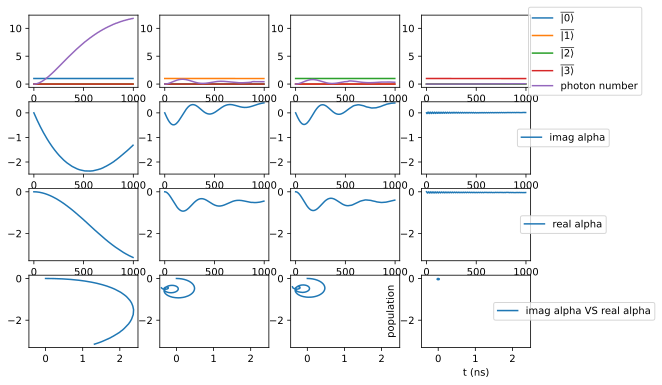

In [10]:
plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,results[0].times,fourier=True)

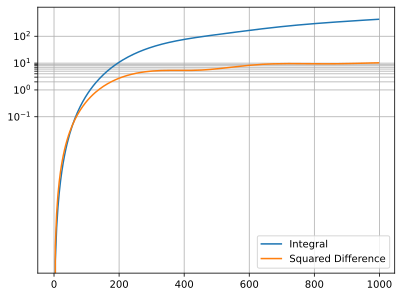

In [12]:
with open('mcsolve_result_try1_0123/averaged.pkl', 'rb') as f:
    results = pickle.load(f)

def compute_contrast(results, res_idx1,res_idx2,# Which two results to compute contrast between
                     kappa, # in GHz
                     a,w_d,tlist,
                     fourier):
    
    # Step-1 compute expectation of alpha and put it in result.expect
    a_op = jnp.array(a.full())

    vectorized_compute_expectation = get_vectorized_compute_expectation_function()

    alphas = []
    for i in [res_idx1,res_idx2]:
        if hasattr(results[i], 'y'):
            states = jnp.array(results[i].y)  # assuming y contains JAX arrays or density matrices (obtained from qiskit solver)
        elif hasattr(results[i], 'states'):
            states = jnp.stack([jnp.array(q.full()) for q in results[i].states])  # assuming states contains QObj or density matrices (obtained from qutip-like solver)
        
        alpha_expect = vectorized_compute_expectation(states, a_op)
        alphas.append(alpha_expect)

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(alphas[0],tlist)
    else:
        first_dominant_freq = w_d

    alphas[0] = alphas[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    alphas[1] = alphas[1]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


    # Step-2 do integration
    squared_diff = np.square(abs(alphas[0]-alphas[1]))
    integrals = [0.0]
    for i in range(1,len(tlist)):
        integrals.append(integrals[i-1]+
                         (tlist[i]-tlist[i-1])*kappa*squared_diff[i]
                         )
    # Step-3 Plot
    plt.figure()
    plt.plot(tlist, integrals, label='Integral')
    plt.plot(tlist, squared_diff, label='Squared Difference')
    plt.yscale('log')
    plt.yticks([0.1,1, 2, 3, 4, 5, 6, 7, 8, 9, 10,100])
    plt.legend()
    plt.grid()
    plt.show()

compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                kappa = 0.07, #np.square(0.07),
                a = a,w_d = w_d,tlist = results[0].times,
                fourier = True)

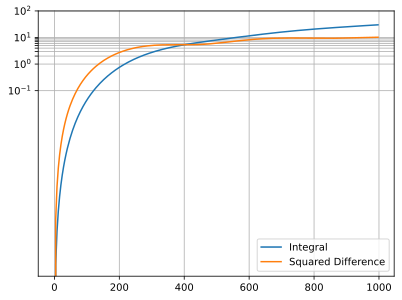

In [13]:

compute_contrast(results = results, 
                 res_idx1= 0, 
                 res_idx2 = 1,
                kappa = np.square(0.07),
                a = a,w_d = w_d,tlist = results[0].times,
                fourier = True)